# Experiment 6: Random Forests

## Objective
Implement ensemble learning using a Random Forest classifier.

## Dataset
This experiment continues with the **Student Performance dataset** used in Experiments 2–5. The model predicts:

- `pass_fail = 0` → Fail
- `pass_fail = 1` → Pass

## Requirements
Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn, Jupyter/Google Colab, and `student_performance.csv`.

## Learning Outcomes
Students will learn to:

1. Explain ensemble learning, bootstrapping and random feature selection.
2. Prepare data without leakage.
3. Build a Random Forest classifier.
4. Compare it with a single Decision Tree and a majority baseline.
5. Evaluate accuracy, precision, recall, F1-score, ROC-AUC and confusion matrix.
6. Interpret feature importance and individual predictions.
7. examine the effect of the number of trees.

## 1. Concept: From One Tree to a Forest

A Random Forest combines many decision trees.

For each tree:

1. A **bootstrap sample** is drawn from the training set with replacement.
2. At each split, only a random subset of features is considered.
3. The tree produces a class vote.

The forest predicts the class receiving the most votes. Averaging many diverse trees generally reduces the high variance of a single decision tree.

### Important Hyperparameters

- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_leaf`: minimum samples required in a leaf
- `max_features`: features considered at each split
- `bootstrap`: whether bootstrap samples are used
- `class_weight`: optional weighting for imbalanced classes
- `random_state`: reproducibility

Random Forests do not normally require feature scaling.

## 2. Import Required Libraries

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Previous Dataset

Keep `student_performance.csv` in the same folder as this notebook or update `DATA_PATH`.

In [3]:
DATA_PATH = Path("/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "student_performance.csv was not found. Place it beside this notebook "
        "or change DATA_PATH to its location."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (1000, 15)


,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1000 non-null   int64  
 1   name                   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   age                    1000 non-null   int64  
 4   class                  1000 non-null   object 
 5   teacher_id             1000 non-null   int64  
 6   subject                1000 non-null   object 
 7   test1_score            1000 non-null   float64
 8   test2_score            1000 non-null   float64
 9   final_exam_score       1000 non-null   float64
 10  final_grade_letter     1000 non-null   object 
 11  attendance_percentage  1000 non-null   float64
 12  study_hours_per_week   1000 non-null   float64
 13  assignments_submitted  1000 non-null   float64
 14  pass_fail              1000 non-null   int64  
dtypes: fl

## 4. Select Features and Target

The following pre-examination variables are used:

- `test1_score`
- `test2_score`
- `attendance_percentage`
- `study_hours_per_week`
- `assignments_submitted`

`final_exam_score` and `final_grade_letter` are excluded because they may reveal the result and cause **target leakage**. Student names and IDs are also excluded from the predictors.

In [4]:
FEATURES = [
    "test1_score",
    "test2_score",
    "attendance_percentage",
    "study_hours_per_week",
    "assignments_submitted"
]
TARGET = "pass_fail"

missing_columns = sorted(set(FEATURES + [TARGET]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df.drop_duplicates().copy()
print("Exact duplicate rows removed:", len(df) - len(data))

# Validate target
numeric_target = pd.to_numeric(data[TARGET], errors="coerce")
invalid_target = data[TARGET].notna() & (
    numeric_target.isna() | ~numeric_target.isin([0, 1])
)
if invalid_target.any():
    raise ValueError("pass_fail must contain only 0, 1, or missing values.")

print("Rows with missing target removed:", numeric_target.isna().sum())
data[TARGET] = numeric_target
data = data.dropna(subset=[TARGET]).copy()
data[TARGET] = data[TARGET].astype(int)

# Convert input columns to numeric; the pipeline will impute missing values
data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="coerce")
data[FEATURES] = data[FEATURES].replace([np.inf, -np.inf], np.nan)

if set(data[TARGET].unique()) != {0, 1}:
    raise ValueError("Both Fail (0) and Pass (1) records are required.")

display(data[FEATURES].isna().sum().to_frame("Missing Values"))
display(data[FEATURES].describe().round(2))

Exact duplicate rows removed: 0
Rows with missing target removed: 0


,Missing Values
test1_score,0
test2_score,0
attendance_percentage,0
study_hours_per_week,0
assignments_submitted,0


,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,63.94,66.13,82.14,4.26,68.98
std,14.76,14.95,6.90,2.29,14.09
min,17.10,24.40,63.90,0.00,22.80
25%,53.80,56.38,77.20,2.60,59.28
50%,64.00,65.70,82.10,4.10,68.50
75%,73.90,76.93,86.80,5.82,79.10
max,100.00,100.00,100.00,12.00,100.00


## 5. Examine Class Distribution

,Class,Count,Percentage
0,Fail,170,17.0
1,Pass,830,83.0


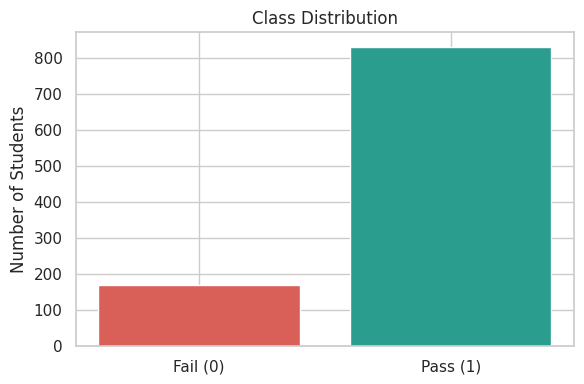

In [5]:
class_counts = data[TARGET].value_counts().reindex([0, 1], fill_value=0)

class_table = pd.DataFrame({
    "Class": ["Fail", "Pass"],
    "Count": class_counts.to_numpy(),
    "Percentage": (100 * class_counts / class_counts.sum()).to_numpy()
})
display(class_table.round(2))

plt.figure(figsize=(6, 4))
plt.bar(["Fail (0)", "Pass (1)"], class_counts.to_numpy(),
        color=["#d95f59", "#2a9d8f"])
plt.title("Class Distribution")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

## 6. Split Training and Testing Data

An 80:20 split is used.

- If each student occurs once, a stratified split preserves the class ratio.
- If students have repeated records, a grouped split keeps the same student out of both partitions.

Imputation is performed **after** splitting so test-set information does not influence training.

In [6]:
X = data[FEATURES]
y = data[TARGET]

repeated_students = (
    "student_id" in data.columns and data["student_id"].duplicated().any()
)

if repeated_students:
    if data["student_id"].isna().any():
        raise ValueError("Resolve missing student IDs before grouped splitting.")

    splitter = GroupShuffleSplit(
        n_splits=1, test_size=0.20, random_state=RANDOM_STATE
    )
    train_idx, test_idx = next(
        splitter.split(X, y, groups=data["student_id"])
    )
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    assert set(data.loc[X_train.index, "student_id"]).isdisjoint(
        set(data.loc[X_test.index, "student_id"])
    )
    print("Student-grouped split used.")
else:
    if y.value_counts().min() < 2:
        raise ValueError("At least two records from each class are required.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
    print("Stratified split used.")

if y_train.nunique() != 2 or y_test.nunique() != 2:
    raise ValueError("Both classes must occur in training and testing sets.")

if X_train.isna().all().any():
    raise ValueError("A feature is entirely missing in the training set.")

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
display(pd.DataFrame({
    "Training": y_train.value_counts(),
    "Testing": y_test.value_counts()
}).rename(index={0: "Fail", 1: "Pass"}))

Stratified split used.
Training samples: 800
Testing samples : 200


,Training,Testing
pass_fail,,
Pass,664,166
Fail,136,34


## 7. Build and Train the Random Forest

The pipeline learns median replacements only from the training set.

This teaching model uses 200 trees. `max_depth=6` and `min_samples_leaf=3` limit tree complexity. `max_features="sqrt"` introduces diversity by considering only a subset of features at each split. `oob_score=True` evaluates unused out-of-bag records from bootstrap sampling.

In [7]:
random_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        criterion="gini",
        max_depth=6,
        min_samples_leaf=3,
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)
rf_classifier = random_forest.named_steps["classifier"]

print("Random Forest trained successfully.")
print("Number of trees:", len(rf_classifier.estimators_))
print("Out-of-bag score:", round(rf_classifier.oob_score_, 4))

Random Forest trained successfully.
Number of trees: 200
Out-of-bag score: 0.9613


## 8. Generate Predictions

The model returns both predicted classes and estimated Pass probabilities. Tree-vote probabilities are estimates, not guarantees.

In [8]:
y_pred = random_forest.predict(X_test)
pass_probability = random_forest.predict_proba(X_test)[:, 1]

prediction_table = X_test.copy()
prediction_table["Actual"] = y_test.map({0: "Fail", 1: "Pass"})
prediction_table["P(Pass)"] = pass_probability
prediction_table["Predicted"] = pd.Series(
    y_pred, index=X_test.index
).map({0: "Fail", 1: "Pass"})
prediction_table["Correct"] = y_test.to_numpy() == y_pred

display(prediction_table.head(15).round(3))

,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted,Actual,P(Pass),Predicted,Correct
438,62.3,56.1,64.5,3.1,35.3,Fail,0.097,Fail,True
875,43.6,42.5,71.7,0.0,52.4,Fail,0.044,Fail,True
154,62.0,73.1,90.6,5.0,66.3,Pass,1.000,Pass,True
664,57.4,59.0,80.1,3.9,66.9,Pass,0.999,Pass,True
984,45.1,44.4,77.2,2.7,68.6,Fail,0.302,Fail,True
476,70.4,86.0,93.8,5.5,88.1,Pass,1.000,Pass,True
406,60.3,62.2,78.7,1.5,53.3,Pass,0.959,Pass,True
912,52.4,69.5,75.4,2.7,52.2,Pass,0.937,Pass,True
12,56.8,61.4,79.4,3.3,58.5,Pass,0.999,Pass,True
854,56.0,47.9,83.8,1.9,67.4,Pass,0.910,Pass,True


## 9. Compare Three Models

The Random Forest is compared with:

1. **Majority baseline:** always predicts the most frequent training class.
2. **Single Decision Tree:** one depth-limited tree.
3. **Random Forest:** 200 diverse trees.

All models use the same training and testing records.

In [9]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

decision_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)

models = {
    "Majority Baseline": baseline,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

evaluation_rows = []

for name, fitted_model in models.items():
    predicted = fitted_model.predict(X_test)
    probabilities = fitted_model.predict_proba(X_test)
    positive_index = list(fitted_model.classes_).index(1)
    evaluation_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision (Pass)": precision_score(
            y_test, predicted, zero_division=0
        ),
        "Recall (Pass)": recall_score(
            y_test, predicted, zero_division=0
        ),
        "F1 (Pass)": f1_score(
            y_test, predicted, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities[:, positive_index]
        )
    })

comparison = pd.DataFrame(evaluation_rows).set_index("Model")
display(comparison.round(4))

,Accuracy,Precision (Pass),Recall (Pass),F1 (Pass),ROC-AUC
Model,,,,,
Majority Baseline,0.830,0.8300,1.0000,0.9071,0.5000
Decision Tree,0.965,0.9818,0.9759,0.9789,0.9871
Random Forest,0.980,0.9880,0.9880,0.9880,0.9972


## 10. Detailed Classification Report

The report provides separate results for Fail and Pass. This is important because accuracy may hide weak performance on the smaller class.

In [10]:
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Fail", "Pass"],
    zero_division=0
))

              precision    recall  f1-score   support

        Fail       0.94      0.94      0.94        34
        Pass       0.99      0.99      0.99       166

    accuracy                           0.98       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.98      0.98      0.98       200



## 11. Confusion Matrix

Rows show actual classes and columns show predicted classes.

- **TN:** Actual Fail, Predicted Fail
- **FP:** Actual Fail, Predicted Pass
- **FN:** Actual Pass, Predicted Fail
- **TP:** Actual Pass, Predicted Pass

A false positive may incorrectly treat an at-risk student as likely to pass.

True Negatives : 32
False Positives: 2
False Negatives: 2
True Positives : 164


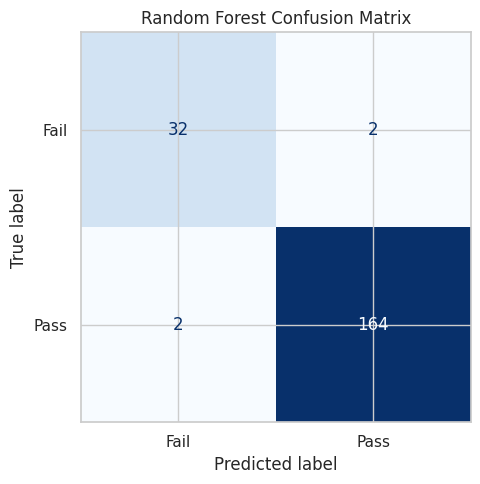

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. ROC Curve

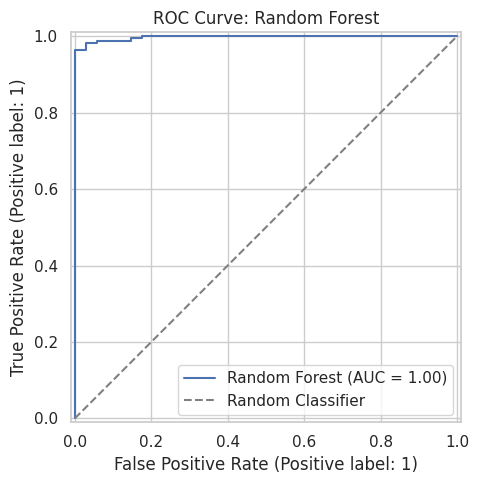

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    pass_probability,
    name="Random Forest",
    ax=ax
)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")
ax.set_title("ROC Curve: Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Feature Importance

Impurity-based importance measures how much each feature reduces impurity across all trees. The values sum to 1.

Importance does not prove causation. Correlated features may divide importance, and a feature unused by this forest is not necessarily useless in every model.

,Importance
assignments_submitted,0.3463
test1_score,0.2713
test2_score,0.2569
attendance_percentage,0.0983
study_hours_per_week,0.0272


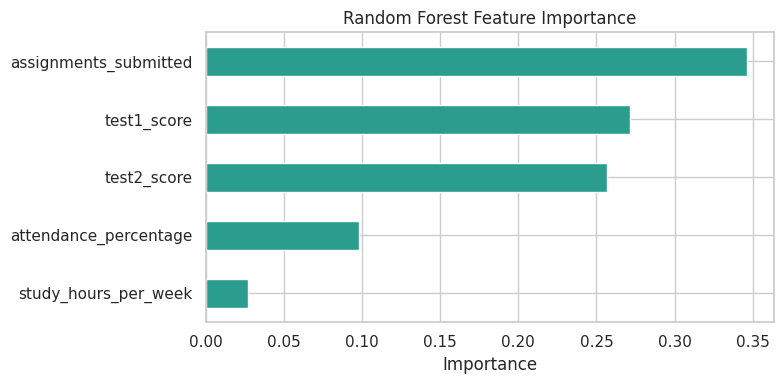

In [13]:
feature_importance = pd.Series(
    rf_classifier.feature_importances_,
    index=FEATURES,
    name="Importance"
).sort_values(ascending=False)

display(feature_importance.to_frame().round(4))

plt.figure(figsize=(8, 4))
feature_importance.sort_values().plot(
    kind="barh",
    color="#2a9d8f"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14. How Many Trees Are Enough?

Train several forests using the **same predefined settings and split**, changing only `n_estimators`. Training and test accuracy are displayed for demonstration.

Do not choose the final number of trees from the test curve. Proper selection should use cross-validation within the training set.

,Number of Trees,Training Accuracy,Testing Accuracy
0,1,0.9575,0.940
1,10,0.9838,0.965
2,25,0.9838,0.975
3,50,0.9875,0.975
4,100,0.9862,0.975
5,200,0.9862,0.980
6,300,0.9875,0.980


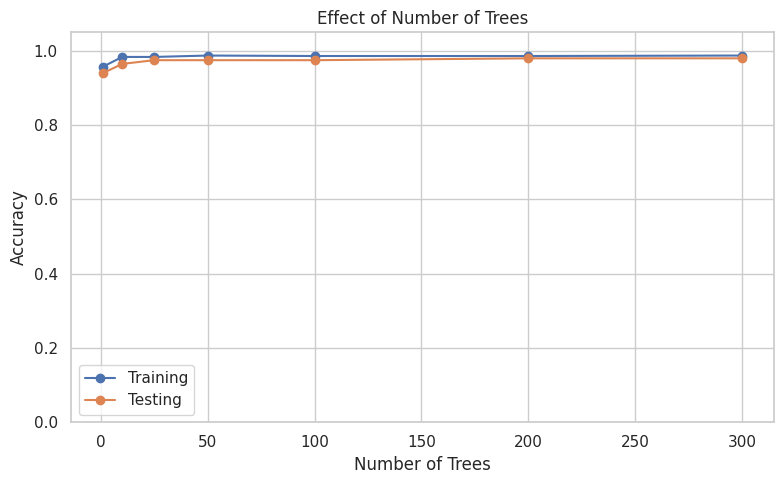

In [14]:
tree_counts = [1, 10, 25, 50, 100, 200, 300]
training_accuracy = []
testing_accuracy = []

for count in tree_counts:
    experiment_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
            n_estimators=count,
            max_depth=6,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    experiment_model.fit(X_train, y_train)
    training_accuracy.append(experiment_model.score(X_train, y_train))
    testing_accuracy.append(experiment_model.score(X_test, y_test))

tree_count_results = pd.DataFrame({
    "Number of Trees": tree_counts,
    "Training Accuracy": training_accuracy,
    "Testing Accuracy": testing_accuracy
})
display(tree_count_results.round(4))

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, training_accuracy, marker="o", label="Training")
plt.plot(tree_counts, testing_accuracy, marker="o", label="Testing")
plt.title("Effect of Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 15. Predict for a New Student

This record is hypothetical. Values must use the same units as the original dataset. The prediction should support, not automatically determine, academic decisions.

In [15]:
new_student = pd.DataFrame([{
    "test1_score": 65,
    "test2_score": 70,
    "attendance_percentage": 85,
    "study_hours_per_week": 12,
    "assignments_submitted": 90
}])

new_prediction = random_forest.predict(new_student)[0]
new_probability = random_forest.predict_proba(new_student)[0, 1]

print("Predicted class:", "Pass" if new_prediction == 1 else "Fail")
print(f"Estimated probability of Pass: {new_probability:.2%}")

Predicted class: Pass
Estimated probability of Pass: 100.00%


## 16. Optional: Inspect Votes from Individual Trees

Each tree casts one vote. The proportion of votes is useful for understanding how the ensemble arrives at its result. It is not necessarily identical to `predict_proba`, because `predict_proba` averages each tree's leaf probability, not only its hard class vote.

In [16]:
transformed_student = random_forest.named_steps["imputer"].transform(
    new_student
)

individual_votes = np.array([
    estimator.predict(transformed_student)[0]
    for estimator in rf_classifier.estimators_
], dtype=int)

vote_summary = pd.Series(individual_votes).value_counts().reindex(
    [0, 1], fill_value=0
)

display(pd.DataFrame({
    "Class": ["Fail", "Pass"],
    "Tree Votes": vote_summary.to_numpy(),
    "Vote Percentage": 100 * vote_summary.to_numpy() / len(individual_votes)
}).round(2))

,Class,Tree Votes,Vote Percentage
0,Fail,0,0.0
1,Pass,200,100.0


## 17. Conclusion

A Random Forest classifier was implemented to predict whether a student will Pass or Fail. It combines bootstrap sampling, random feature selection and voting across multiple decision trees. The model was evaluated with accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix and an out-of-bag score. It was also compared with a majority baseline and a single decision tree.

### Observation Template

“Using ___ training records and ___ testing records, the Random Forest achieved accuracy ___, F1-score ___ and ROC-AUC ___. Its out-of-bag score was ___. Compared with the single Decision Tree, the Random Forest ___. The most important feature was ___.”

### Limitations

- Results depend on the quality and timing of the recorded features.
- Feature importance is not causal.
- Class imbalance can distort accuracy.
- Hyperparameters should be tuned using training-only cross-validation.
- Predictions should not replace human academic judgement.

## Viva Questions with Short Answers

1. **What is ensemble learning?** Combining multiple models to obtain a more stable or accurate prediction.
2. **What is a Random Forest?** An ensemble of decision trees trained using bootstrap samples and random feature subsets.
3. **What is bootstrapping?** Sampling training records with replacement.
4. **What is bagging?** Training models on bootstrap samples and aggregating their predictions.
5. **Why are random features used?** To reduce similarity among trees and increase diversity.
6. **How is the final classification made?** Through majority voting; probabilities are averaged across trees.
7. **Why does Random Forest reduce overfitting?** Averaging many diverse trees reduces variance.
8. **Does it require feature scaling?** Normally, no.
9. **What is an out-of-bag sample?** A training record not selected in a particular tree's bootstrap sample.
10. **What is the OOB score?** An internal performance estimate based on out-of-bag predictions.
11. **What does `n_estimators` control?** The number of trees.
12. **What does `max_features` control?** The number of candidate features considered at each split.
13. **What is feature importance?** A model-based measure of a feature's contribution to impurity reduction.
14. **Why compare with a baseline?** To verify that the model adds predictive value.
15. **Random Forest versus one tree?** A single tree is easier to interpret; a forest is usually more stable but less transparent.
16. **Can Random Forest handle multiclass classification?** Yes.
17. **What is target leakage?** Using information that reveals the target or would be unavailable at prediction time.

## Practice Exercises

1. Change `max_depth` and observe training versus testing accuracy.
2. Compare `max_features="sqrt"`, `"log2"` and `None` using cross-validation.
3. Try `class_weight="balanced"` and examine Fail recall.
4. Use training-only cross-validation to tune `n_estimators`, `max_depth` and `min_samples_leaf`.
5. Compare Experiments 4, 5 and 6 using identical rows, split and metrics.